<a href="https://colab.research.google.com/github/gokhangokcen1/machine-learning-journey/blob/main/01-python4data-science/06_project_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Veri setine bakış

In [ ]:
df_netflix = pd.read_csv("netflix_titles.csv")
df_netflix.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [ ]:
df_netflix.shape

(8807, 12)

In [ ]:
df_netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


# Eksik verileri bulma

In [ ]:
df_netflix.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [ ]:
for column in df_netflix.columns:
    percentage = df_netflix[column].isnull().mean()
    print(f'{column}: {round(percentage*100, 2)}%')

show_id: 0.0%
type: 0.0%
title: 0.0%
director: 29.91%
cast: 9.37%
country: 9.44%
date_added: 0.11%
release_year: 0.0%
rating: 0.05%
duration: 0.03%
listed_in: 0.0%
description: 0.0%


# Eksik verilerle ilgilenme

In [ ]:
# Remove a column or row with .drop, .dropna or .isnull

df_netflix = df_netflix.drop("director", axis=1)

# drop row
# no_director = df_netflix[df_netflix['director'].isnull()].index
# df_netflix.drop(no_director, axis=0)
# # drop row
# # no_duration = df_netflix[df_netflix['duration'].isnull()].index
# # df_netflix.drop(no_duration, axis=0, inplace=True)

# # ~ + .isnull()
# df_netflix[~df_netflix['director'].isnull()]

# # dropna()
# df_netflix.dropna(subset=['director'])

In [ ]:
df_netflix.head(3)

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [ ]:
df_netflix["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [ ]:
# Replace it by the mean, median (numeric data) or mode (categorical data)

df_netflix[df_netflix['rating'].isnull()]
mode = ''.join(df_netflix['rating'].mode())
df_netflix['rating'].fillna(mode, inplace=True)

C:\Users\gokha\AppData\Local\Temp\ipykernel_20860\3762963006.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_netflix['rating'].fillna(mode, inplace=True)


In [ ]:
df_netflix["rating"].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [ ]:
df_netflix[df_netflix['duration'].isnull()]

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [ ]:
df_netflix.loc[5541]

show_id                                                     s5542
type                                                        Movie
title                                             Louis C.K. 2017
cast                                                   Louis C.K.
country                                             United States
date_added                                          April 4, 2017
release_year                                                 2017
rating                                                     74 min
duration                                                      NaN
listed_in                                                  Movies
description     Louis C.K. muses on religion, eternal love, gi...
Name: 5541, dtype: object

In [ ]:
# Replace it by an arbitrary number with .fillna()
df_netflix['duration'].fillna('0', inplace=True)

# backward, forward
# df.fillna(method='bfill')
# df.fillna(method='ffill')

In [ ]:
df_netflix.loc[5541]

show_id                                                     s5542
type                                                        Movie
title                                             Louis C.K. 2017
cast                                                   Louis C.K.
country                                             United States
date_added                                          April 4, 2017
release_year                                                 2017
rating                                                     74 min
duration                                                   10 min
listed_in                                                  Movies
description     Louis C.K. muses on religion, eternal love, gi...
Name: 5541, dtype: object

In [ ]:
df_netflix["duration"].value_counts()

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
             ... 
5 min           1
16 min          1
186 min         1
193 min         1
191 min         1
Name: count, Length: 220, dtype: int64

# Dışta kalan (outlier) veriler

In [ ]:
df_netflix['duration'].str.extract(r'(\d+)', expand=True).loc[5541]

0    10
Name: 5541, dtype: object

In [ ]:
df_netflix['rating'].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [ ]:
df_netflix['duration'].str.split(n=0, expand=True)[0].astype(int)

0        90
1         2
2         1
3         1
4         2
       ... 
8802    158
8803      2
8804     88
8805     88
8806    111
Name: 0, Length: 8807, dtype: int64

In [ ]:
# selecting only movies
df_movie = df_netflix[df_netflix['type']=='Movie']

# Split Strings by Characters with the str.split Method
df_movie = df_movie.assign(minute = df_movie['duration'].str.split(expand=True)[0].astype(int))
# df_movie = df_movie.assign(minute = df_movie['duration'].str.extract(r'(\d+)', expand=True))

## Using histograms to identify outliers within numeric data

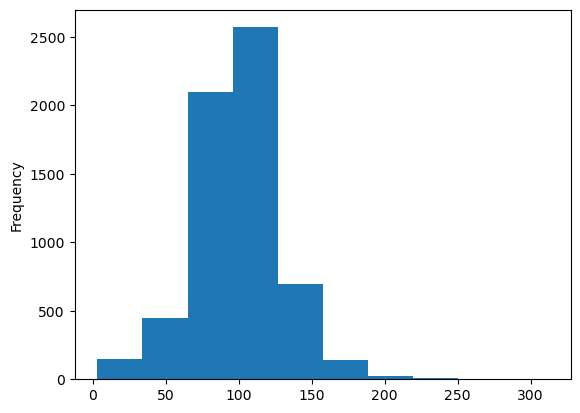

In [ ]:
# make histogram with pandas
ax = df_movie['minute'].plot(kind='hist', bins=10)

In [ ]:
df_movie['minute']

0        90
6        91
7       125
9       104
12      127
       ... 
8801     96
8802    158
8804     88
8805     88
8806    111
Name: minute, Length: 6131, dtype: int64

In [ ]:
# get bar ranges with value_counts method and numbers of bins
df_movie['minute'].value_counts(bins=10).sort_index()

(2.69, 33.9]       150
(33.9, 64.8]       450
(64.8, 95.7]      2095
(95.7, 126.6]     2569
(126.6, 157.5]     692
(157.5, 188.4]     144
(188.4, 219.3]      22
(219.3, 250.2]       6
(250.2, 281.1]       2
(281.1, 312.0]       1
Name: count, dtype: int64

In [ ]:
# Dealing with outliers
df_movie[(df_movie['minute']<64.8) | (df_movie['minute']>157.5)].head()

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
22,s23,Movie,Avvai Shanmughi,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...,161
23,s24,Movie,Go! Go! Cory Carson: Chrissy Takes the Wheel,"Maisie Benson, Paul Killam, Kerry Gudjohnsen, ...",NaN,"September 21, 2021",2021,TV-Y,61 min,Children & Family Movies,From arcade games to sled days and hiccup cure...,61
24,s25,Movie,Jeans,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,166
45,s46,Movie,My Heroes Were Cowboys,NaN,NaN,"September 16, 2021",2021,PG,23 min,Documentaries,Robin Wiltshire's painful childhood was rescue...,23
71,s72,Movie,A StoryBots Space Adventure,"Evan Spiridellis, Erin Fitzgerald, Jeff Gill, ...",NaN,"September 14, 2021",2021,TV-Y,13 min,Children & Family Movies,Join the StoryBots and the space travelers of ...,13


## Using boxplot to identify outliers within numeric data

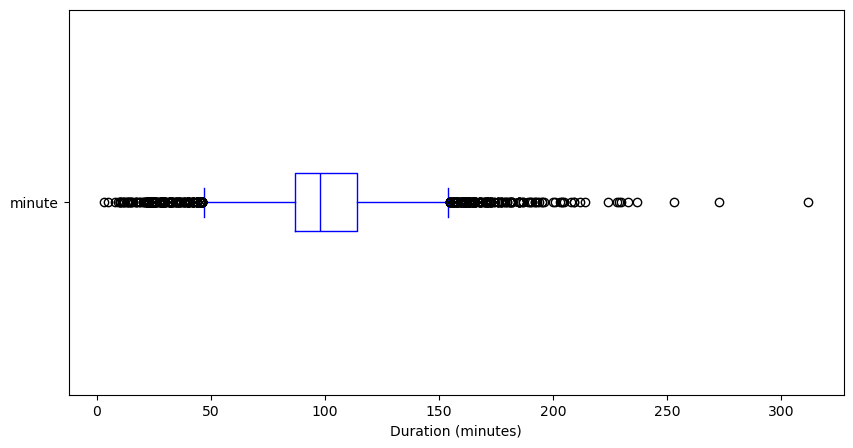

In [ ]:
# make a boxplot with pandas
df_movie['minute'].plot(kind='box', vert=False, color='blue',
                        figsize=(10,5))

plt.xlabel('Duration (minutes)')
plt.show()

In [ ]:
# overview descriptive statitics
# IQR = Q3-Q1
min_boxplot = 87 - 1.5*(114 - 87) # Q1 - 1.5*IQR
max_boxplot = 114 + 1.5*(114 - 87) # Q3 + 1.5*IQR

print(df_movie['minute'].describe())
print(min_boxplot)
print(max_boxplot)

count    6131.000000
mean       99.533355
std        28.352972
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: minute, dtype: float64
46.5
154.5


In [ ]:
# Dealing with Outliers
df_movie[(df_movie['minute']<46.5) | (df_movie['minute']>154.5)]

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
22,s23,Movie,Avvai Shanmughi,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...,161
24,s25,Movie,Jeans,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,166
45,s46,Movie,My Heroes Were Cowboys,NaN,NaN,"September 16, 2021",2021,PG,23 min,Documentaries,Robin Wiltshire's painful childhood was rescue...,23
71,s72,Movie,A StoryBots Space Adventure,"Evan Spiridellis, Erin Fitzgerald, Jeff Gill, ...",NaN,"September 14, 2021",2021,TV-Y,13 min,Children & Family Movies,Join the StoryBots and the space travelers of ...,13
73,s74,Movie,King of Boys,"Sola Sobowale, Adesua Etomi, Remilekun ""Remini...",Nigeria,"September 14, 2021",2018,TV-MA,182 min,"Dramas, International Movies",When a powerful businesswoman’s political ambi...,182
...,...,...,...,...,...,...,...,...,...,...,...,...
8763,s8764,Movie,WWII: Report from the Aleutians,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...,45
8764,s8765,Movie,Wyatt Earp,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,"January 1, 2020",1994,PG-13,191 min,Action & Adventure,Legendary lawman Wyatt Earp is continually at ...,191
8770,s8771,Movie,Yaadein,"Jackie Shroff, Hrithik Roshan, Kareena Kapoor,...",India,"March 1, 2018",2001,TV-14,171 min,"Dramas, International Movies, Romantic Movies",Two young lovers set out to overcome the obsta...,171
8788,s8789,Movie,You Carry Me,"Lana Baric, Vojislav Brajovic, Natasa Janjic, ...","Croatia, Slovenia, Serbia, Montenegro","July 1, 2016",2015,TV-MA,157 min,"Dramas, International Movies","A soap opera producer, director and makeup art...",157


## Using bars to identify outliers within categorical data

<Axes: xlabel='rating'>

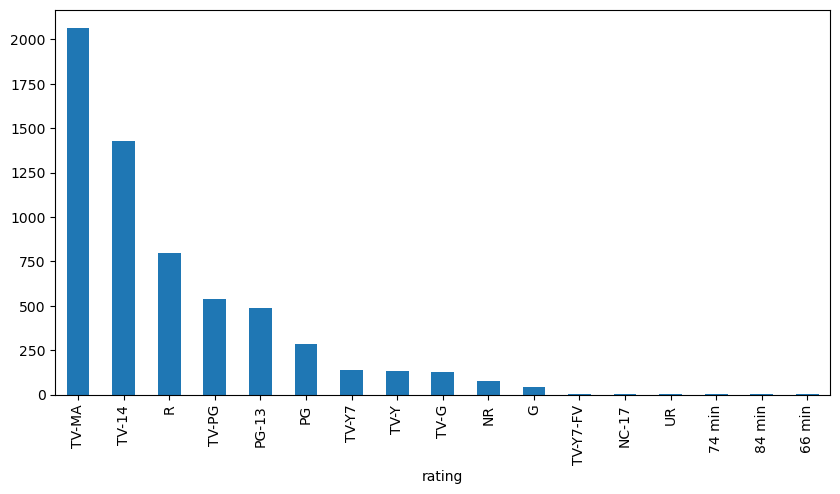

In [ ]:
# make barplot with pandas
df_movie['rating'].value_counts().plot(kind='bar', figsize=(10,5))

# Text Normalization

## Dealing with inconsistent capitalization: lower(), upper(), title()

In [ ]:
# change the case of text with the str attribute
df_movie['title'].str.lower()
df_movie['title'].str.upper()
df_movie['title'].str.title()

# update values
df_movie['title'] = df_movie['title'].str.upper()

# change the case of text with the apply method
df_movie['title'].apply(lambda x:x.lower())

0                   dick johnson is dead
6       my little pony: a new generation
7                                sankofa
9                           the starling
12                          je suis karl
                      ...               
8801                             zinzana
8802                              zodiac
8804                          zombieland
8805                                zoom
8806                              zubaan
Name: title, Length: 6131, dtype: object

## Remove blank spaces with strip(), lstrip(), and rstrip()

In [ ]:
# how the strip method workds
movie_title = " Titanic    "

# trim leading space with lstrip()
print(movie_title.lstrip())
# trim trailing space with rstrip()
print(movie_title.rstrip())
# trim leading and trailing space with strip()
print(movie_title.strip())

Titanic    
 Titanic
Titanic


In [ ]:
# get rid of leading and trailing white spaces with the strip() method
df_movie['title'] = df_movie['title'].str.strip()

# get rid of leading and trailing white spaces with the apply method
df_movie['title'].apply(lambda x:x.strip())

0                   DICK JOHNSON IS DEAD
6       MY LITTLE PONY: A NEW GENERATION
7                                SANKOFA
9                           THE STARLING
12                          JE SUIS KARL
                      ...               
8801                             ZINZANA
8802                              ZODIAC
8804                          ZOMBIELAND
8805                                ZOOM
8806                              ZUBAAN
Name: title, Length: 6131, dtype: object

## Replace strings with replace() or sub()

In [ ]:
# remove punctuation signs with the str.replace() method and regex
df_movie['title'].str.replace('[^\w\s]', '', regex=True)

# remove punctuation signs with the replace() method and regex
df_movie['title'].replace('[^\w\s]', '', regex=True)

# difference between str.replace() and replace()
# str.replace(): perform string or regex substitution on string data.
# replace():  can replace any type of data

# df_movie['title'].replace(1, 2, regex=True)
# df_movie['title'].str.replace(1, 2, regex=True)

# remove punctuation signs with the re.sub() function via teh apply method
# import re
# df_movie['title'].apply(lambda x:re.sub('[^\w\s]','',x))

0                  DICK JOHNSON IS DEAD
6       MY LITTLE PONY A NEW GENERATION
7                               SANKOFA
9                          THE STARLING
12                         JE SUIS KARL
                     ...               
8801                            ZINZANA
8802                             ZODIAC
8804                         ZOMBIELAND
8805                               ZOOM
8806                             ZUBAAN
Name: title, Length: 6131, dtype: object